# Transplant Analysis
- Dependent: Protein creatinine ratio, Albumin excretion 24h, Protein excretion 24h, Proteinuria_spot (qualitative present/absent), Proteinuria_24h (qualitative present/absent), Creatinine, Cystatin_C, eGFR_sCr, eGFR_Cystatin, CKD (qualitative, present/absent, which means GFR less than 60 based on Cystatin C)

In [29]:
import math
import subprocess
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is available even in a fresh environment
try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio

data_all = pd.read_csv('renal_all.csv')
data_notransplant = pd.read_csv('renal_notransplant.csv')
data_transplant = pd.read_csv('renal_transplant.csv')

# Additional cohort files
data_mma_non = pd.read_csv('mma_non-transplanted.csv')
data_mma_post = pd.read_csv('mma_post-transplant.csv')
data_pa_non = pd.read_csv('Pa_renal_nontransplanted.csv')
data_pa_post = pd.read_csv('pa_renal_post-transplanted.csv')

data_all.head()


,DOS,VID,Sex,MMAtype0123,ID,Age,Sex_M_F,Transplant,TransplantType,Protein_Creatinine_Ratio,...,Microalbuminuria,Proteinuria_24h,Creatinine,Cystatin_C,eGFR_SCr,eGFR_CystatinC,CKD,PTH_pg_ml,Two_Truncating,CKD_StageCys
0,6/16/2011,VID.10286,0,0,1,5.750000,M,0,,,...,0,0,0.79,1.28,54.160506,56.1753128707481,1,,0,3
1,6/19/2014,VID.10286,0,0,1,8.758333,M,0,,.296,...,1,0,2.38,2.01,21.552353,36.9047656802983,1,115.8,0,3
2,8/20/2007,VID.10094,1,1,2,24.516667,F,0,,.158,...,1,1,0.93,,87.737906,,,,0,
3,8/23/2011,VID.10094,1,1,2,28.525000,F,0,,.162,...,,,0.97,.94,81.360607,89.25,0,,0,2
4,6/12/2017,VID.10149,1,1,3,11.813889,F,0,,,...,0,0,0.69,1.02,87.986957,69.3986818745387,0,44.4,0,2


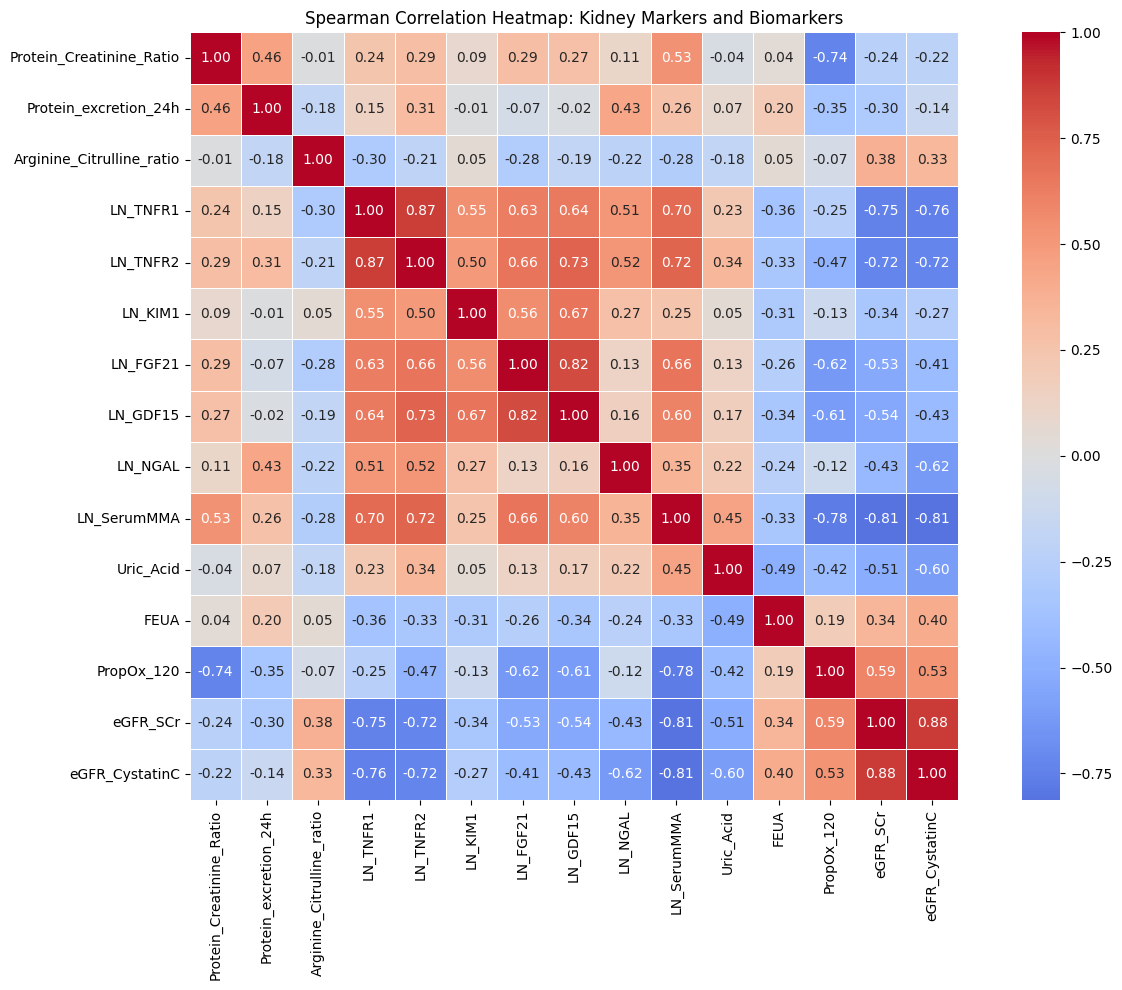

PropOx_120                   0.697917
Protein_excretion_24h        0.572917
LN_GDF15                     0.385417
Protein_Creatinine_Ratio     0.375000
LN_SerumMMA                  0.302083
LN_NGAL                      0.239583
LN_FGF21                     0.229167
FEUA                         0.229167
LN_TNFR1                     0.208333
LN_TNFR2                     0.187500
eGFR_CystatinC               0.166667
LN_KIM1                      0.156250
Uric_Acid                    0.114583
Arginine_Citrulline_ratio    0.052083
eGFR_SCr                     0.000000
LN_RBP4                      0.000000
LN_TGFb1                     0.000000
dtype: float64

In [30]:
# Heatmap for selected clinical + biomarker variables
heatmap_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

# Optional sparse biomarkers are intentionally excluded from the default plot:
# LN_RBP4, LN_TGFb1

heatmap_df = data_all.copy()
for col in heatmap_vars:
    heatmap_df[col] = pd.to_numeric(heatmap_df[col], errors='coerce')

corr_matrix = heatmap_df[heatmap_vars].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title('Spearman Correlation Heatmap: Kidney Markers and Biomarkers')
plt.tight_layout()
plt.show()

# Quick completeness check for sparse features
missing_summary = heatmap_df[heatmap_vars + ['LN_RBP4', 'LN_TGFb1']].isna().mean().sort_values(ascending=False)
missing_summary

Kept targets for multi-output modeling: ['Protein_excretion_24h', 'Albumin_excretion_24h', 'Protein_Creatinine_Ratio', 'Cystatin_C', 'eGFR_CystatinC', 'Creatinine', 'eGFR_SCr']
Rows used for model: 96
Mean CV R2: -8.658 +/- 16.370
Mean CV RMSE (macro): 71.733
Mean CV MAE (macro): 21.965


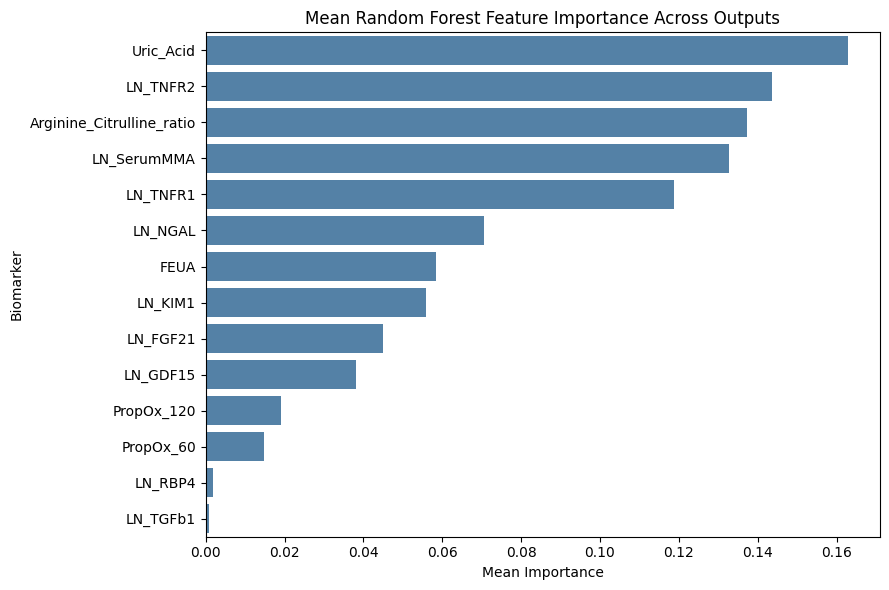

,feature,mean_importance
10,Uric_Acid,0.162884
2,LN_TNFR2,0.143560
0,Arginine_Citrulline_ratio,0.137404
9,LN_SerumMMA,0.132763
1,LN_TNFR1,0.118703
6,LN_NGAL,0.070498
11,FEUA,0.058384
3,LN_KIM1,0.056008
4,LN_FGF21,0.044950
5,LN_GDF15,0.038086


In [31]:
# Multi-output modeling: predict dependent variables from selected biomarkers
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

# Dependent variables from notebook description (using dataset column names)
dependent_vars = [
    'Protein_Creatinine_Ratio',
    'Albumin_excretion_24h',
    'Protein_excretion_24h',
    'Creatinine',
    'Cystatin_C',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

# Independent biomarkers requested
independent_vars = [
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_RBP4',
    'LN_TGFb1',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_60',
    'PropOx_120',
]

model_df = data_all[independent_vars + dependent_vars].copy()

# Coerce numeric
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Drop targets that are mostly missing to keep a stable multi-output target matrix
target_missing = model_df[dependent_vars].isna().mean().sort_values(ascending=False)
kept_targets = target_missing[target_missing <= 0.60].index.tolist()

# Keep rows with at least one target present, then impute Y so multi-output model can run
model_df = model_df.loc[model_df[kept_targets].notna().any(axis=1)].copy()
X = model_df[independent_vars]
Y = model_df[kept_targets]

x_preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), independent_vars),
    ],
    remainder='drop'
)

y_imputer = SimpleImputer(strategy='median')
Y_imputed = pd.DataFrame(
    y_imputer.fit_transform(Y),
    columns=kept_targets,
    index=Y.index,
)

rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )
)

pipeline = Pipeline([
    ('x_preprocess', x_preprocess),
    ('rf_multi', rf),
])

# Evaluation: multi-output R2 + error-based metrics
def rmse_macro(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))

def mae_macro(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred, multioutput='uniform_average')

scoring = {
    'r2': 'r2',
    'rmse_macro': make_scorer(rmse_macro, greater_is_better=False),
    'mae_macro': make_scorer(mae_macro, greater_is_better=False),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline,
    X,
    Y_imputed,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

print('Kept targets for multi-output modeling:', kept_targets)
print('Rows used for model:', len(X))
print(f"Mean CV R2: {cv_results['test_r2'].mean():.3f} +/- {cv_results['test_r2'].std():.3f}")
print(f"Mean CV RMSE (macro): {-cv_results['test_rmse_macro'].mean():.3f}")
print(f"Mean CV MAE (macro): {-cv_results['test_mae_macro'].mean():.3f}")

# Fit final model on all available rows
pipeline.fit(X, Y_imputed)

# Aggregate feature importance across all output models
feature_names = independent_vars
all_importances = np.array([
    est.feature_importances_ for est in pipeline.named_steps['rf_multi'].estimators_
])
mean_importance = all_importances.mean(axis=0)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': mean_importance,
}).sort_values('mean_importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='mean_importance', y='feature', color='steelblue')
plt.title('Mean Random Forest Feature Importance Across Outputs')
plt.xlabel('Mean Importance')
plt.ylabel('Biomarker')
plt.tight_layout()
plt.show()

importance_df

In [32]:
# -----------------------------
# Grouped comparison setup
# -----------------------------
comparison_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Albumin_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_60',
    'PropOx_120',
    'Creatinine',
    'Cystatin_C',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

plot_df = data_all.copy()
for col in comparison_vars:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# Robust normalization for grouping columns
plot_df['Transplant_norm'] = pd.to_numeric(plot_df['Transplant'], errors='coerce')
plot_df['TransplantType_norm'] = (
    plot_df['TransplantType']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown'})
)

# Build a clear group label for comparison
plot_df['Group'] = np.where(
    plot_df['Transplant_norm'] == 0,
    'Non-Transplant',
    'Transplant-' + plot_df['TransplantType_norm']
)

# Standardize common transplant labels
plot_df['Group'] = plot_df['Group'].replace({
    'Transplant-l': 'Transplant-L',
    'Transplant-lk': 'Transplant-LK',
    'Transplant-k': 'Transplant-K',
})

group_order = [
    'Non-Transplant',
    'Transplant-L',
    'Transplant-LK',
    'Transplant-K',
    'Transplant-Unknown',
]
# Keep observed groups and append any additional unexpected groups
observed_groups = plot_df['Group'].dropna().unique().tolist()
group_order = [g for g in group_order if g in observed_groups] + [
    g for g in observed_groups if g not in group_order
]

print('Groups available and sample size:')
print(plot_df['Group'].value_counts(dropna=False))

Groups available and sample size:
Group
Non-Transplant    96
Name: count, dtype: int64


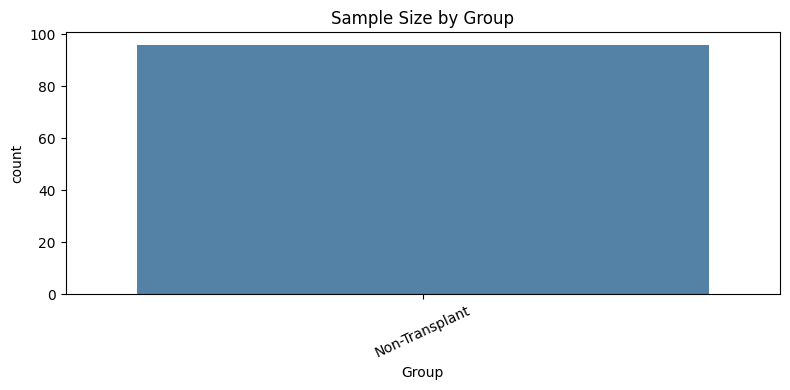

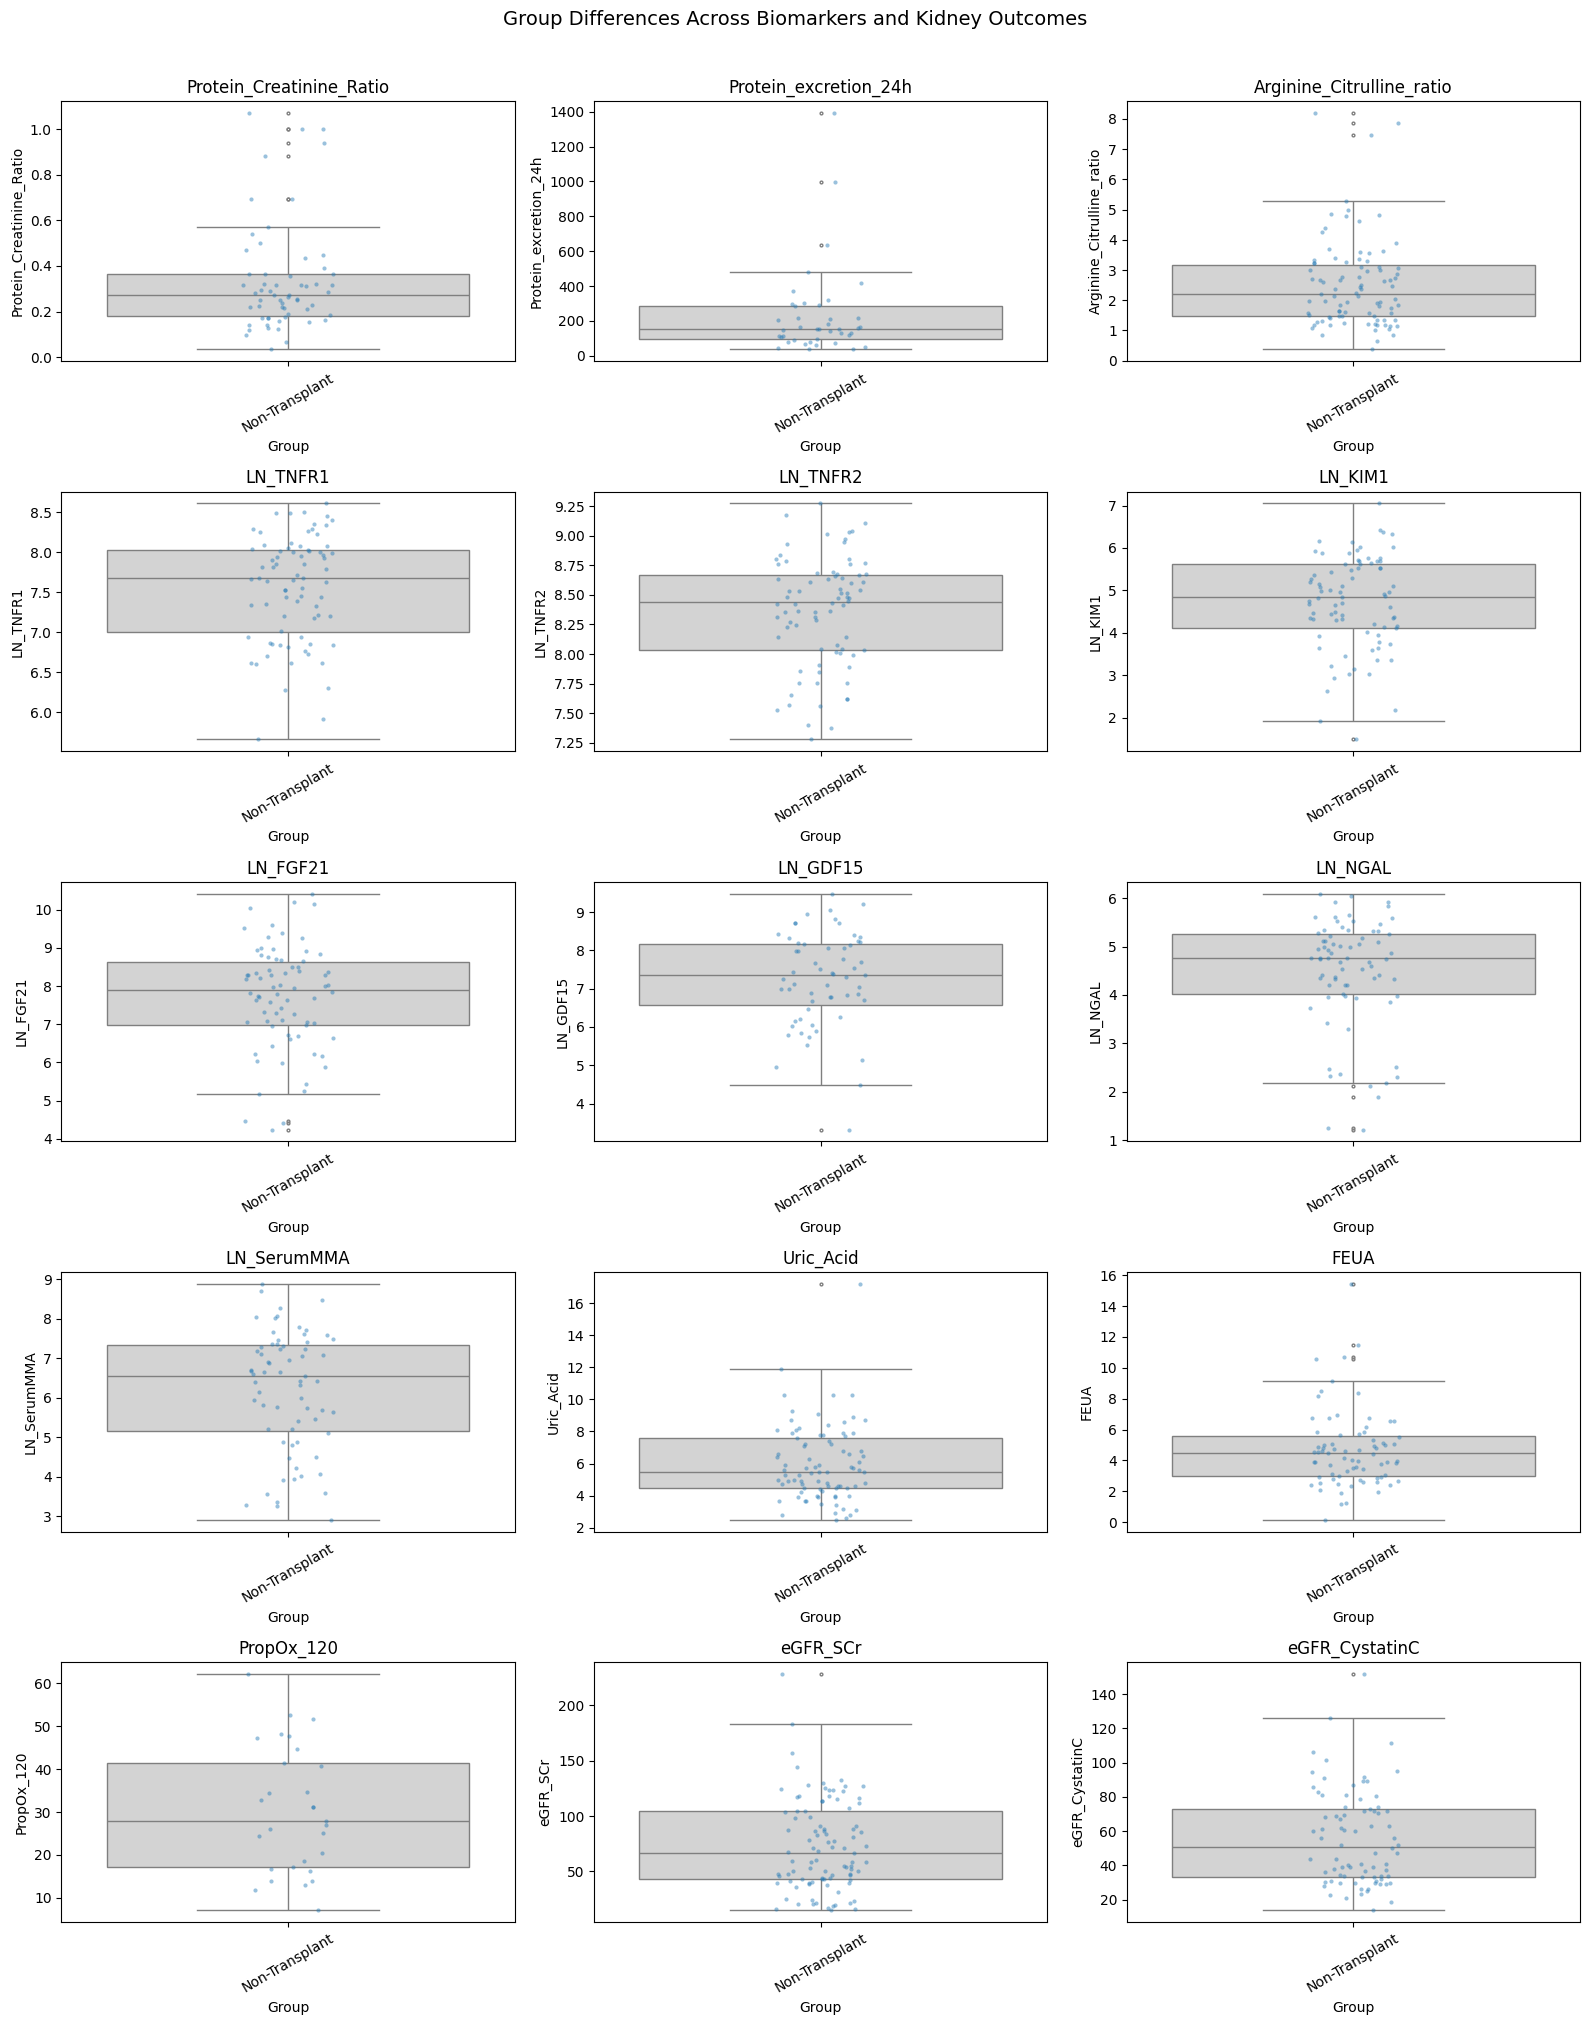

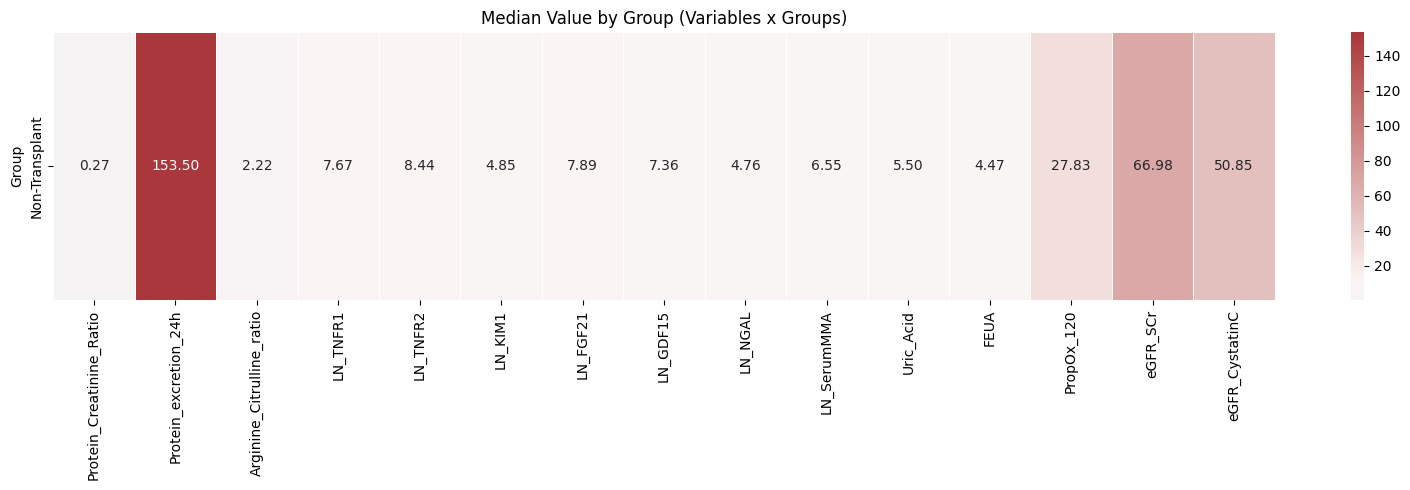

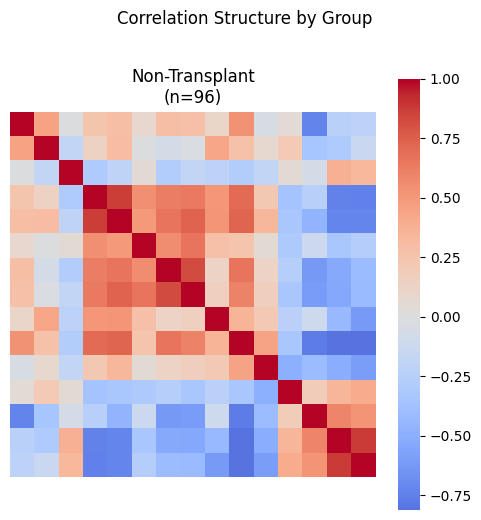

In [33]:
# -----------------------------
# Multi-graph comparisons across groups
# -----------------------------

# 1) Group size bar chart
plt.figure(figsize=(8, 4))
sns.countplot(data=plot_df, x='Group', order=group_order, color='steelblue')
plt.title('Sample Size by Group')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 2) Boxplots for key variables (same visual style across groups)
key_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

ncols = 3
nrows = int(np.ceil(len(key_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    sns.boxplot(
        data=plot_df,
        x='Group',
        y=var,
        order=group_order,
        ax=axes[i],
        color='lightgray',
        fliersize=2,
    )
    sns.stripplot(
        data=plot_df,
        x='Group',
        y=var,
        order=group_order,
        ax=axes[i],
        color='tab:blue',
        alpha=0.45,
        size=3,
    )
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Group Differences Across Biomarkers and Kidney Outcomes', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# 3) Median heatmap by group (good high-level summary)
median_table = plot_df.groupby('Group')[key_vars].median(numeric_only=True).reindex(group_order)

plt.figure(figsize=(16, 5))
sns.heatmap(
    median_table,
    cmap='vlag',
    center=np.nanmedian(median_table.values),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
)
plt.title('Median Value by Group (Variables x Groups)')
plt.tight_layout()
plt.show()

# 4) Group-specific correlation heatmaps (same method as your current approach)
corr_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

n_panels = len(group_order)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5), squeeze=False)

for idx, group_name in enumerate(group_order):
    grp = plot_df.loc[plot_df['Group'] == group_name, corr_vars]
    corr = grp.corr(method='spearman')
    sns.heatmap(
        corr,
        ax=axes[0, idx],
        cmap='coolwarm',
        center=0,
        cbar=(idx == n_panels - 1),
        square=True,
        xticklabels=False,
        yticklabels=False,
    )
    axes[0, idx].set_title(f'{group_name}\n(n={len(grp)})')

plt.suptitle('Correlation Structure by Group', y=1.03)
plt.tight_layout()
plt.show()

## Multi-dataset analyses (MMA + Pa renal) and raw vs log comparison

The cells below repeat the group-comparison workflow for:
- `mma_non-transplanted.csv`
- `mma_post-transplant.csv`
- `Pa_renal_nontransplanted.csv` / `pa_renal_post-transplanted.csv` (raw biomarkers + provided log columns)

They also test whether **log-transforming raw biomarkers** gives the same patterns as using pre-computed `LN_*` columns, and whether **Pa renal** vs **renal_*** files differ (note: Pa renal is mostly a separate patient cohort).

In [35]:
# -----------------------------
# Reusable helpers for all datasets
# -----------------------------
from scipy.stats import permutation_test

BIOMARKER_RAW_TO_LN = {
    'TNFR1': 'LN_TNFR1',
    'TNFR2': 'LN_TNFR2',
    'KIM1': 'LN_KIM1',
    'FGF21': 'LN_FGF21',
    'GDF15': 'LN_GDF15',
    'NGAL': 'LN_NGAL',
    'RBP4': 'LN_RBP4',
    'TGFb1': 'LN_TGFb1',
    'sMMA': 'LN_sMMA',
}

COLUMN_ALIASES = {
    'Arg_Citrulline_Ratio': 'Arginine_Citrulline_ratio',
    'eGFR_CyC': 'eGFR_CystatinC',
    'Screatinine_mg_dL': 'Creatinine',
    'Cystatin_mg_L': 'Cystatin_C',
}

DEFAULT_KEY_VARS = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'LN_sMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]


def standardize_dataframe(df):
    out = df.copy()
    out = out.rename(columns=COLUMN_ALIASES)

    if 'VID' in out.columns:
        out['VID_norm'] = out['VID'].astype(str).str.strip().str.replace(' ', '', regex=False)
    if 'DOS' in out.columns:
        out['DOS_norm'] = pd.to_datetime(out['DOS'], errors='coerce').dt.date.astype(str)

    # Add log(raw) columns when raw biomarkers exist
    for raw_col, ln_col in BIOMARKER_RAW_TO_LN.items():
        if raw_col in out.columns:
            raw_vals = pd.to_numeric(out[raw_col], errors='coerce')
            computed = np.log(raw_vals.where(raw_vals > 0))
            out[f'LOG_{raw_col}'] = computed
            if ln_col in out.columns:
                out[f'DIFF_{ln_col}'] = pd.to_numeric(out[ln_col], errors='coerce') - computed

    return out


def build_group_labels(df):
    out = df.copy()
    out['Transplant_norm'] = pd.to_numeric(out['Transplant'], errors='coerce')

    tx_type = (
        out['TransplantType']
        .fillna('Unknown')
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({'': 'unknown', 'nan': 'unknown', 'none': 'unknown'})
    )

    tx_type = tx_type.replace({
        'l': 'l',
        'liver': 'l',
        'lk': 'lk',
        'k': 'k',
    })

    out['Group'] = np.where(
        out['Transplant_norm'] == 0,
        'Non-Transplant',
        'Transplant-' + tx_type.str.upper()
    )
    out['Group'] = out['Group'].replace({
        'Transplant-L': 'Transplant-L',
        'Transplant-LK': 'Transplant-LK',
        'Transplant-K': 'Transplant-K',
        'Transplant-UNKNOWN': 'Transplant-Unknown',
    })

    preferred = [
        'Non-Transplant',
        'Transplant-L',
        'Transplant-LK',
        'Transplant-K',
        'Transplant-Unknown',
    ]
    observed = out['Group'].dropna().unique().tolist()
    group_order = [g for g in preferred if g in observed] + [g for g in observed if g not in preferred]
    return out, group_order


def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    gt = np.sum(x[:, None] > y[None, :])
    lt = np.sum(x[:, None] < y[None, :])
    return (gt - lt) / (len(x) * len(y))


def cliff_magnitude(delta):
    ad = abs(delta)
    if ad < 0.147:
        return 'negligible'
    if ad < 0.33:
        return 'small'
    if ad < 0.474:
        return 'medium'
    return 'large'


def median_diff_stat(a, b, axis=0):
    return np.nanmedian(a, axis=axis) - np.nanmedian(b, axis=axis)


def coerce_numeric_columns(df, cols):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out


def run_group_visuals(plot_df, group_order, key_vars, dataset_name):
    available_vars = [v for v in key_vars if v in plot_df.columns]
    if len(available_vars) == 0:
        print(f'[{dataset_name}] No requested variables found.')
        return

    print(f'\n=== {dataset_name} ===')
    print(plot_df['Group'].value_counts(dropna=False))

    plt.figure(figsize=(8, 4))
    sns.countplot(data=plot_df, x='Group', order=group_order, color='steelblue')
    plt.title(f'{dataset_name}: Sample Size by Group')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

    ncols = 3
    nrows = int(np.ceil(len(available_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(available_vars):
        sns.boxplot(
            data=plot_df, x='Group', y=var, order=group_order,
            ax=axes[i], color='lightgray', fliersize=2,
        )
        sns.stripplot(
            data=plot_df, x='Group', y=var, order=group_order,
            ax=axes[i], color='tab:blue', alpha=0.45, size=3,
        )
        axes[i].set_title(var)
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'{dataset_name}: Group Differences', y=1.01)
    plt.tight_layout()
    plt.show()

    median_table = plot_df.groupby('Group')[available_vars].median(numeric_only=True).reindex(group_order)
    plt.figure(figsize=(max(10, len(available_vars) * 0.8), 5))
    sns.heatmap(
        median_table,
        cmap='vlag',
        center=np.nanmedian(median_table.values),
        annot=True,
        fmt='.2f',
        linewidths=0.5,
    )
    plt.title(f'{dataset_name}: Median by Group')
    plt.tight_layout()
    plt.show()


def run_sparse_pairwise(plot_df, group_order, key_vars, dataset_name, reference_group='Non-Transplant'):
    available_vars = [v for v in key_vars if v in plot_df.columns]
    plot_df = coerce_numeric_columns(plot_df, available_vars)

    if reference_group not in group_order:
        reference_group = plot_df['Group'].value_counts().index[0]

    comparison_groups = [g for g in group_order if g != reference_group]
    results = []

    for var in available_vars:
        x_ref = plot_df.loc[plot_df['Group'] == reference_group, var].dropna().astype(float).values
        for grp in comparison_groups:
            x_grp = plot_df.loc[plot_df['Group'] == grp, var].dropna().astype(float).values
            if len(x_ref) >= 2 and len(x_grp) >= 2:
                delta = cliffs_delta(x_grp, x_ref)
                n_total = len(x_grp) + len(x_ref)
                n_resamples = 2000 if n_total > 25 else 10000
                perm = permutation_test(
                    (x_grp, x_ref),
                    statistic=median_diff_stat,
                    permutation_type='independent',
                    alternative='two-sided',
                    n_resamples=n_resamples,
                    random_state=42,
                )
                results.append({
                    'Dataset': dataset_name,
                    'Variable': var,
                    'Comparison': f'{grp} vs {reference_group}',
                    'n_group': len(x_grp),
                    'n_reference': len(x_ref),
                    'Cliffs_delta': float(delta),
                    'Effect_magnitude': cliff_magnitude(delta),
                    'Permutation_p': float(perm.pvalue),
                })

    out = pd.DataFrame(results)
    if out.empty:
        print(f'[{dataset_name}] No pairwise tests ran.')
    else:
        out = out.sort_values(['Permutation_p', 'Cliffs_delta'], ascending=[True, False])
        print(f'[{dataset_name}] Top pairwise differences (reference={reference_group}):')
        display(out.head(12))
    return out


=== MMA Non-Transplanted ===
Group
Non-Transplant        96
Transplant-Unknown    15
Name: count, dtype: int64


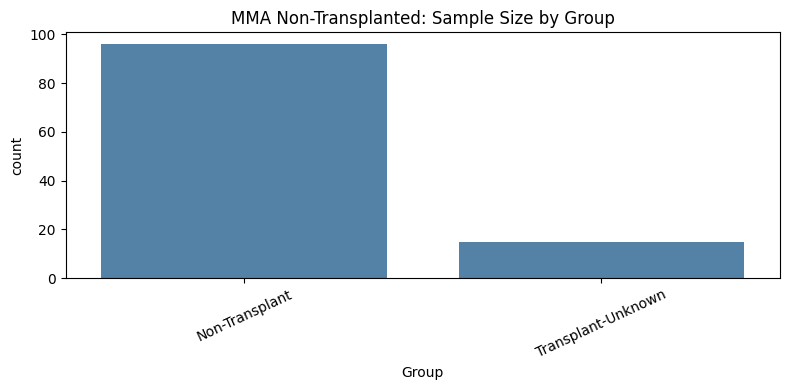

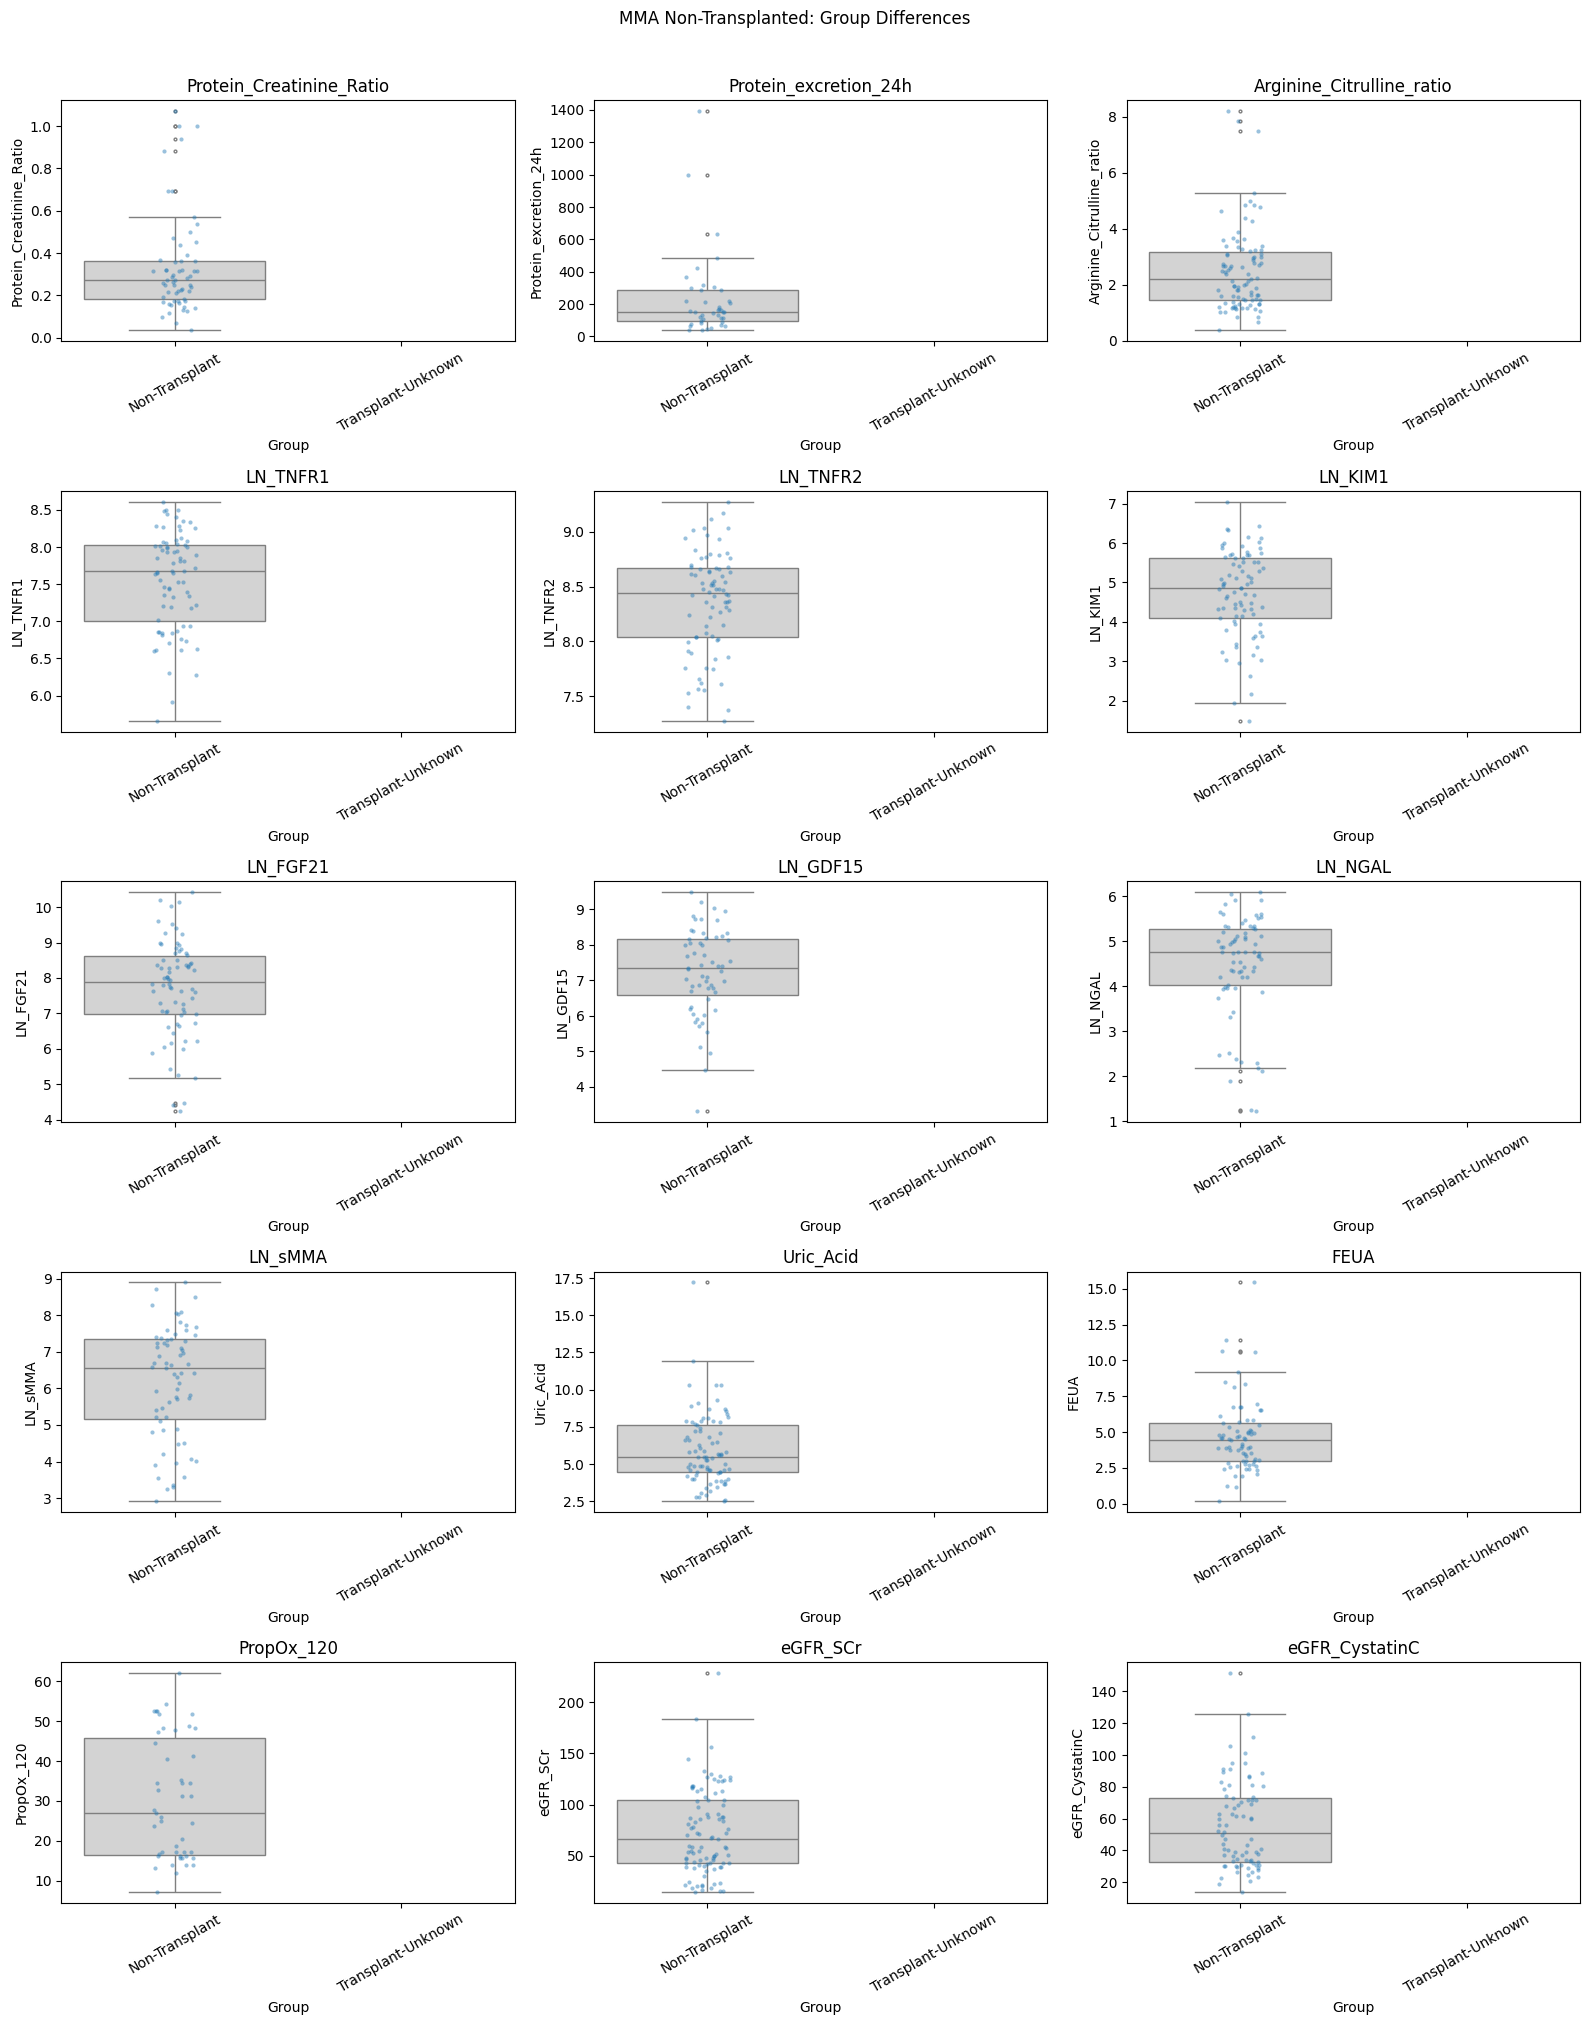

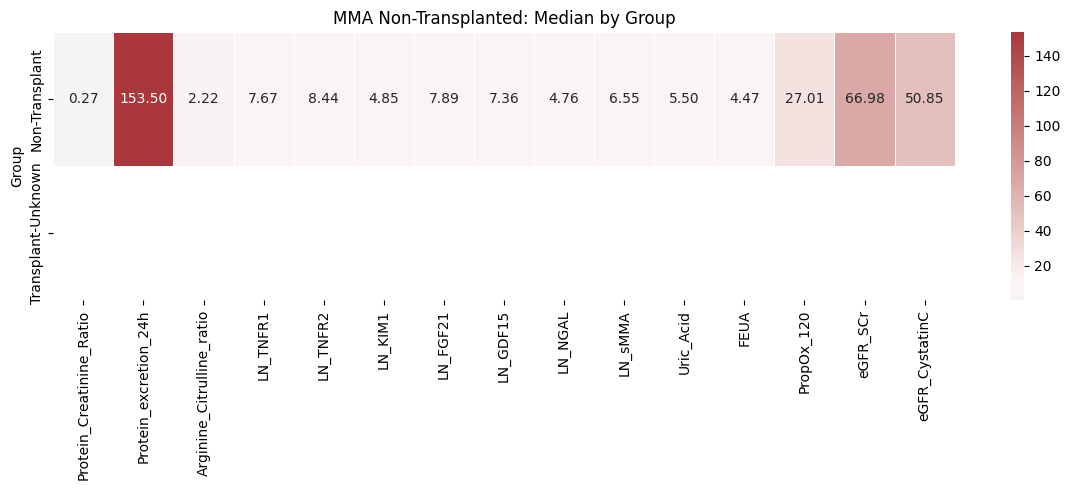

[MMA Non-Transplanted] No pairwise tests ran.

=== MMA Post-Transplant ===
Group
Transplant-L     6
Transplant-LK    5
Transplant-K     4
Name: count, dtype: int64


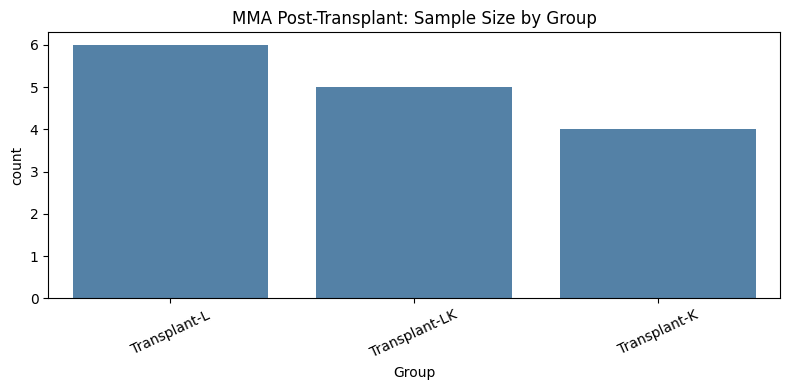

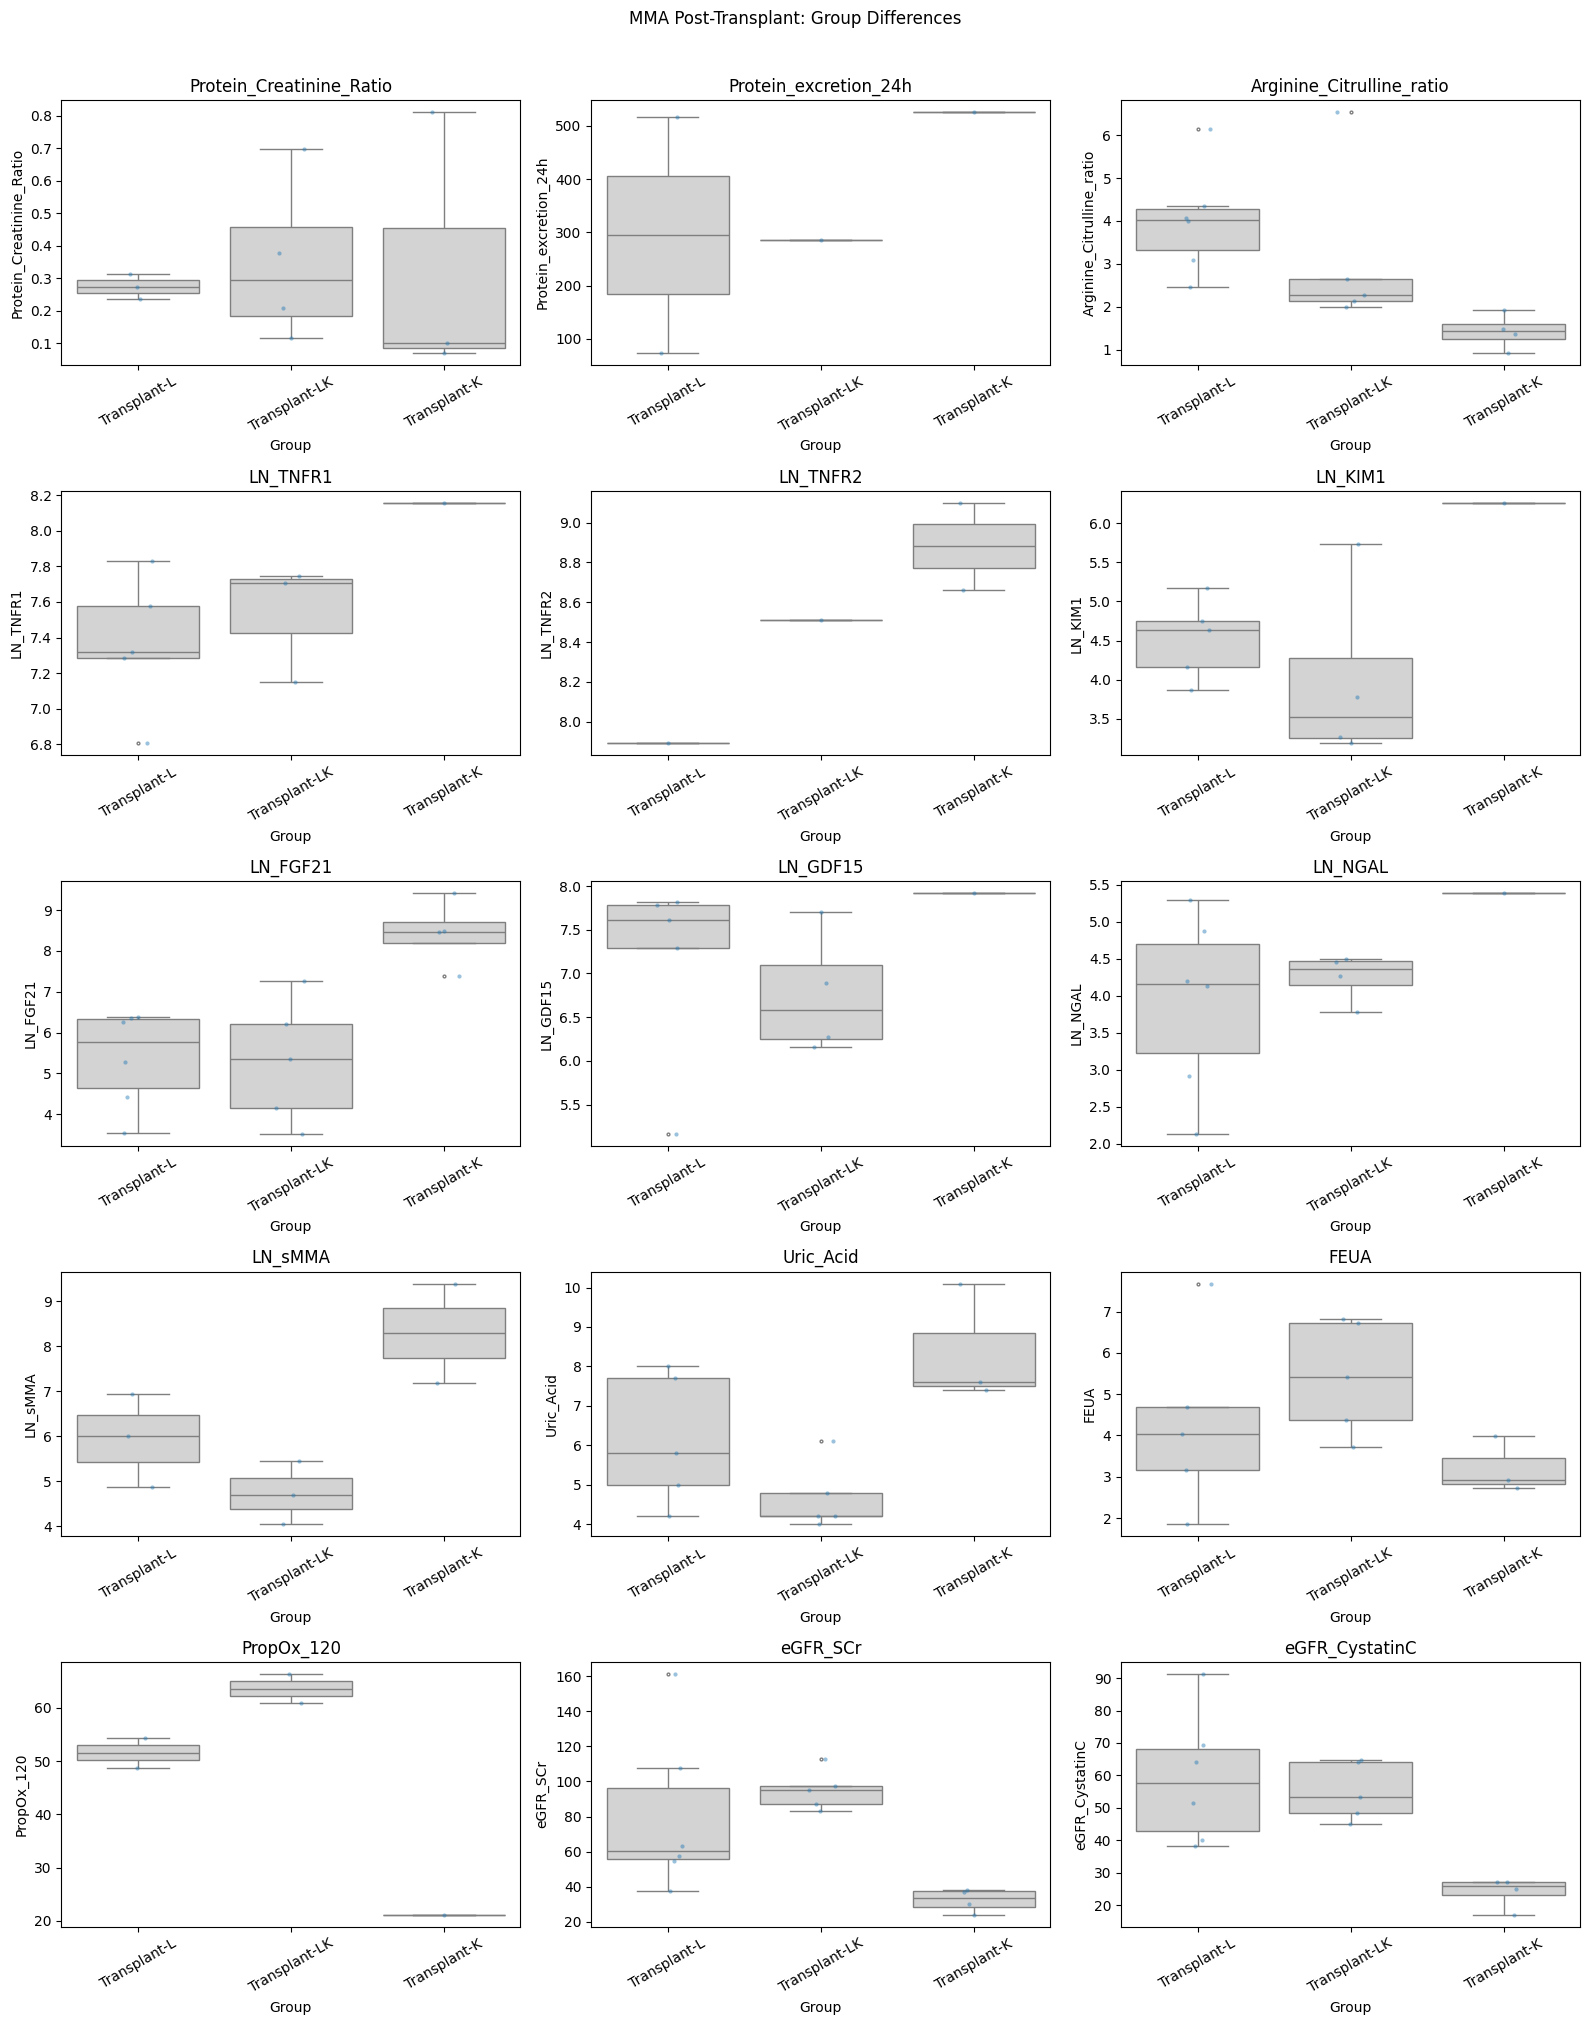

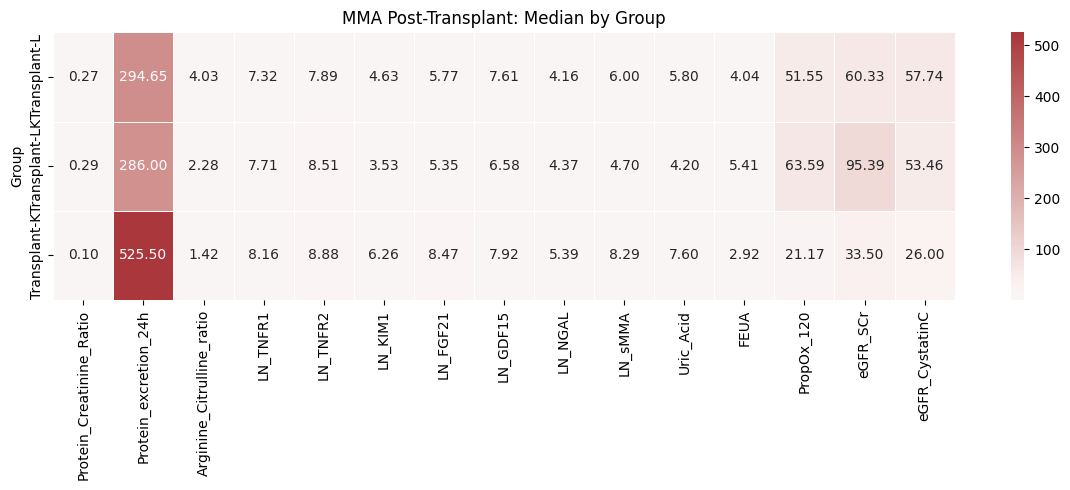

[MMA Post-Transplant] Top pairwise differences (reference=Transplant-L):


,Dataset,Variable,Comparison,n_group,n_reference,Cliffs_delta,Effect_magnitude,Permutation_p
7,MMA Post-Transplant,LN_FGF21,Transplant-K vs Transplant-L,4,6,1.000000,large,0.028571
18,MMA Post-Transplant,eGFR_SCr,Transplant-K vs Transplant-L,4,6,-0.916667,large,0.028571
3,MMA Post-Transplant,Arginine_Citrulline_ratio,Transplant-K vs Transplant-L,4,6,-1.000000,large,0.028571
20,MMA Post-Transplant,eGFR_CystatinC,Transplant-K vs Transplant-L,4,6,-1.000000,large,0.047619
17,MMA Post-Transplant,eGFR_SCr,Transplant-LK vs Transplant-L,5,6,0.400000,medium,0.108225
2,MMA Post-Transplant,Arginine_Citrulline_ratio,Transplant-LK vs Transplant-L,5,6,-0.533333,large,0.116883
5,MMA Post-Transplant,LN_KIM1,Transplant-LK vs Transplant-L,4,5,-0.500000,large,0.126984
11,MMA Post-Transplant,LN_sMMA,Transplant-K vs Transplant-L,2,3,1.000000,large,0.200000
10,MMA Post-Transplant,LN_sMMA,Transplant-LK vs Transplant-L,3,3,-0.777778,large,0.200000
16,MMA Post-Transplant,PropOx_120,Transplant-LK vs Transplant-L,2,2,1.000000,large,0.333333


,Dataset,Variable,Comparison,n_group,n_reference,Cliffs_delta,Effect_magnitude,Permutation_p
0,MMA Post-Transplant,LN_FGF21,Transplant-K vs Transplant-L,4,6,1.000000,large,0.028571
1,MMA Post-Transplant,eGFR_SCr,Transplant-K vs Transplant-L,4,6,-0.916667,large,0.028571
2,MMA Post-Transplant,Arginine_Citrulline_ratio,Transplant-K vs Transplant-L,4,6,-1.000000,large,0.028571
3,MMA Post-Transplant,eGFR_CystatinC,Transplant-K vs Transplant-L,4,6,-1.000000,large,0.047619
4,MMA Post-Transplant,eGFR_SCr,Transplant-LK vs Transplant-L,5,6,0.400000,medium,0.108225
5,MMA Post-Transplant,Arginine_Citrulline_ratio,Transplant-LK vs Transplant-L,5,6,-0.533333,large,0.116883
6,MMA Post-Transplant,LN_KIM1,Transplant-LK vs Transplant-L,4,5,-0.500000,large,0.126984
7,MMA Post-Transplant,LN_sMMA,Transplant-K vs Transplant-L,2,3,1.000000,large,0.200000
8,MMA Post-Transplant,LN_sMMA,Transplant-LK vs Transplant-L,3,3,-0.777778,large,0.200000
9,MMA Post-Transplant,PropOx_120,Transplant-LK vs Transplant-L,2,2,1.000000,large,0.333333


In [36]:
# -----------------------------
# Repeat group analyses for MMA datasets
# -----------------------------

mma_datasets = {
    'MMA Non-Transplanted': data_mma_non,
    'MMA Post-Transplant': data_mma_post,
}

mma_sparse_results = []

for dataset_name, df_raw in mma_datasets.items():
    df = standardize_dataframe(df_raw)
    for col in DEFAULT_KEY_VARS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df, group_order = build_group_labels(df)
    run_group_visuals(df, group_order, DEFAULT_KEY_VARS, dataset_name)
    res = run_sparse_pairwise(df, group_order, DEFAULT_KEY_VARS, dataset_name)
    if not res.empty:
        mma_sparse_results.append(res)

if mma_sparse_results:
    mma_sparse_all = pd.concat(mma_sparse_results, ignore_index=True)
    display(mma_sparse_all.head(20))
else:
    mma_sparse_all = pd.DataFrame()


=== Pa Renal Non-Transplanted ===
Group
Non-Transplant    46
Name: count, dtype: int64


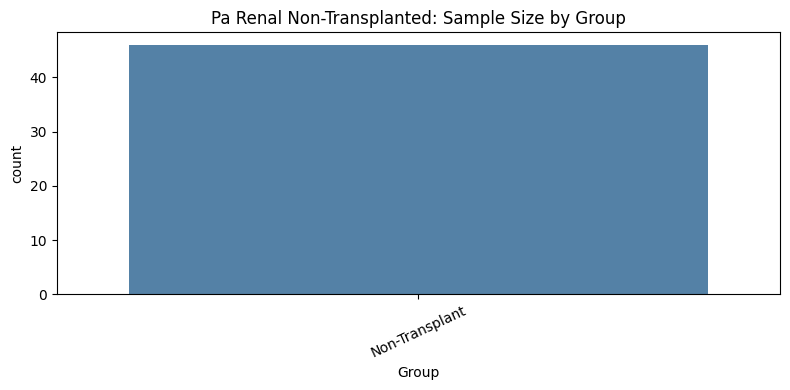

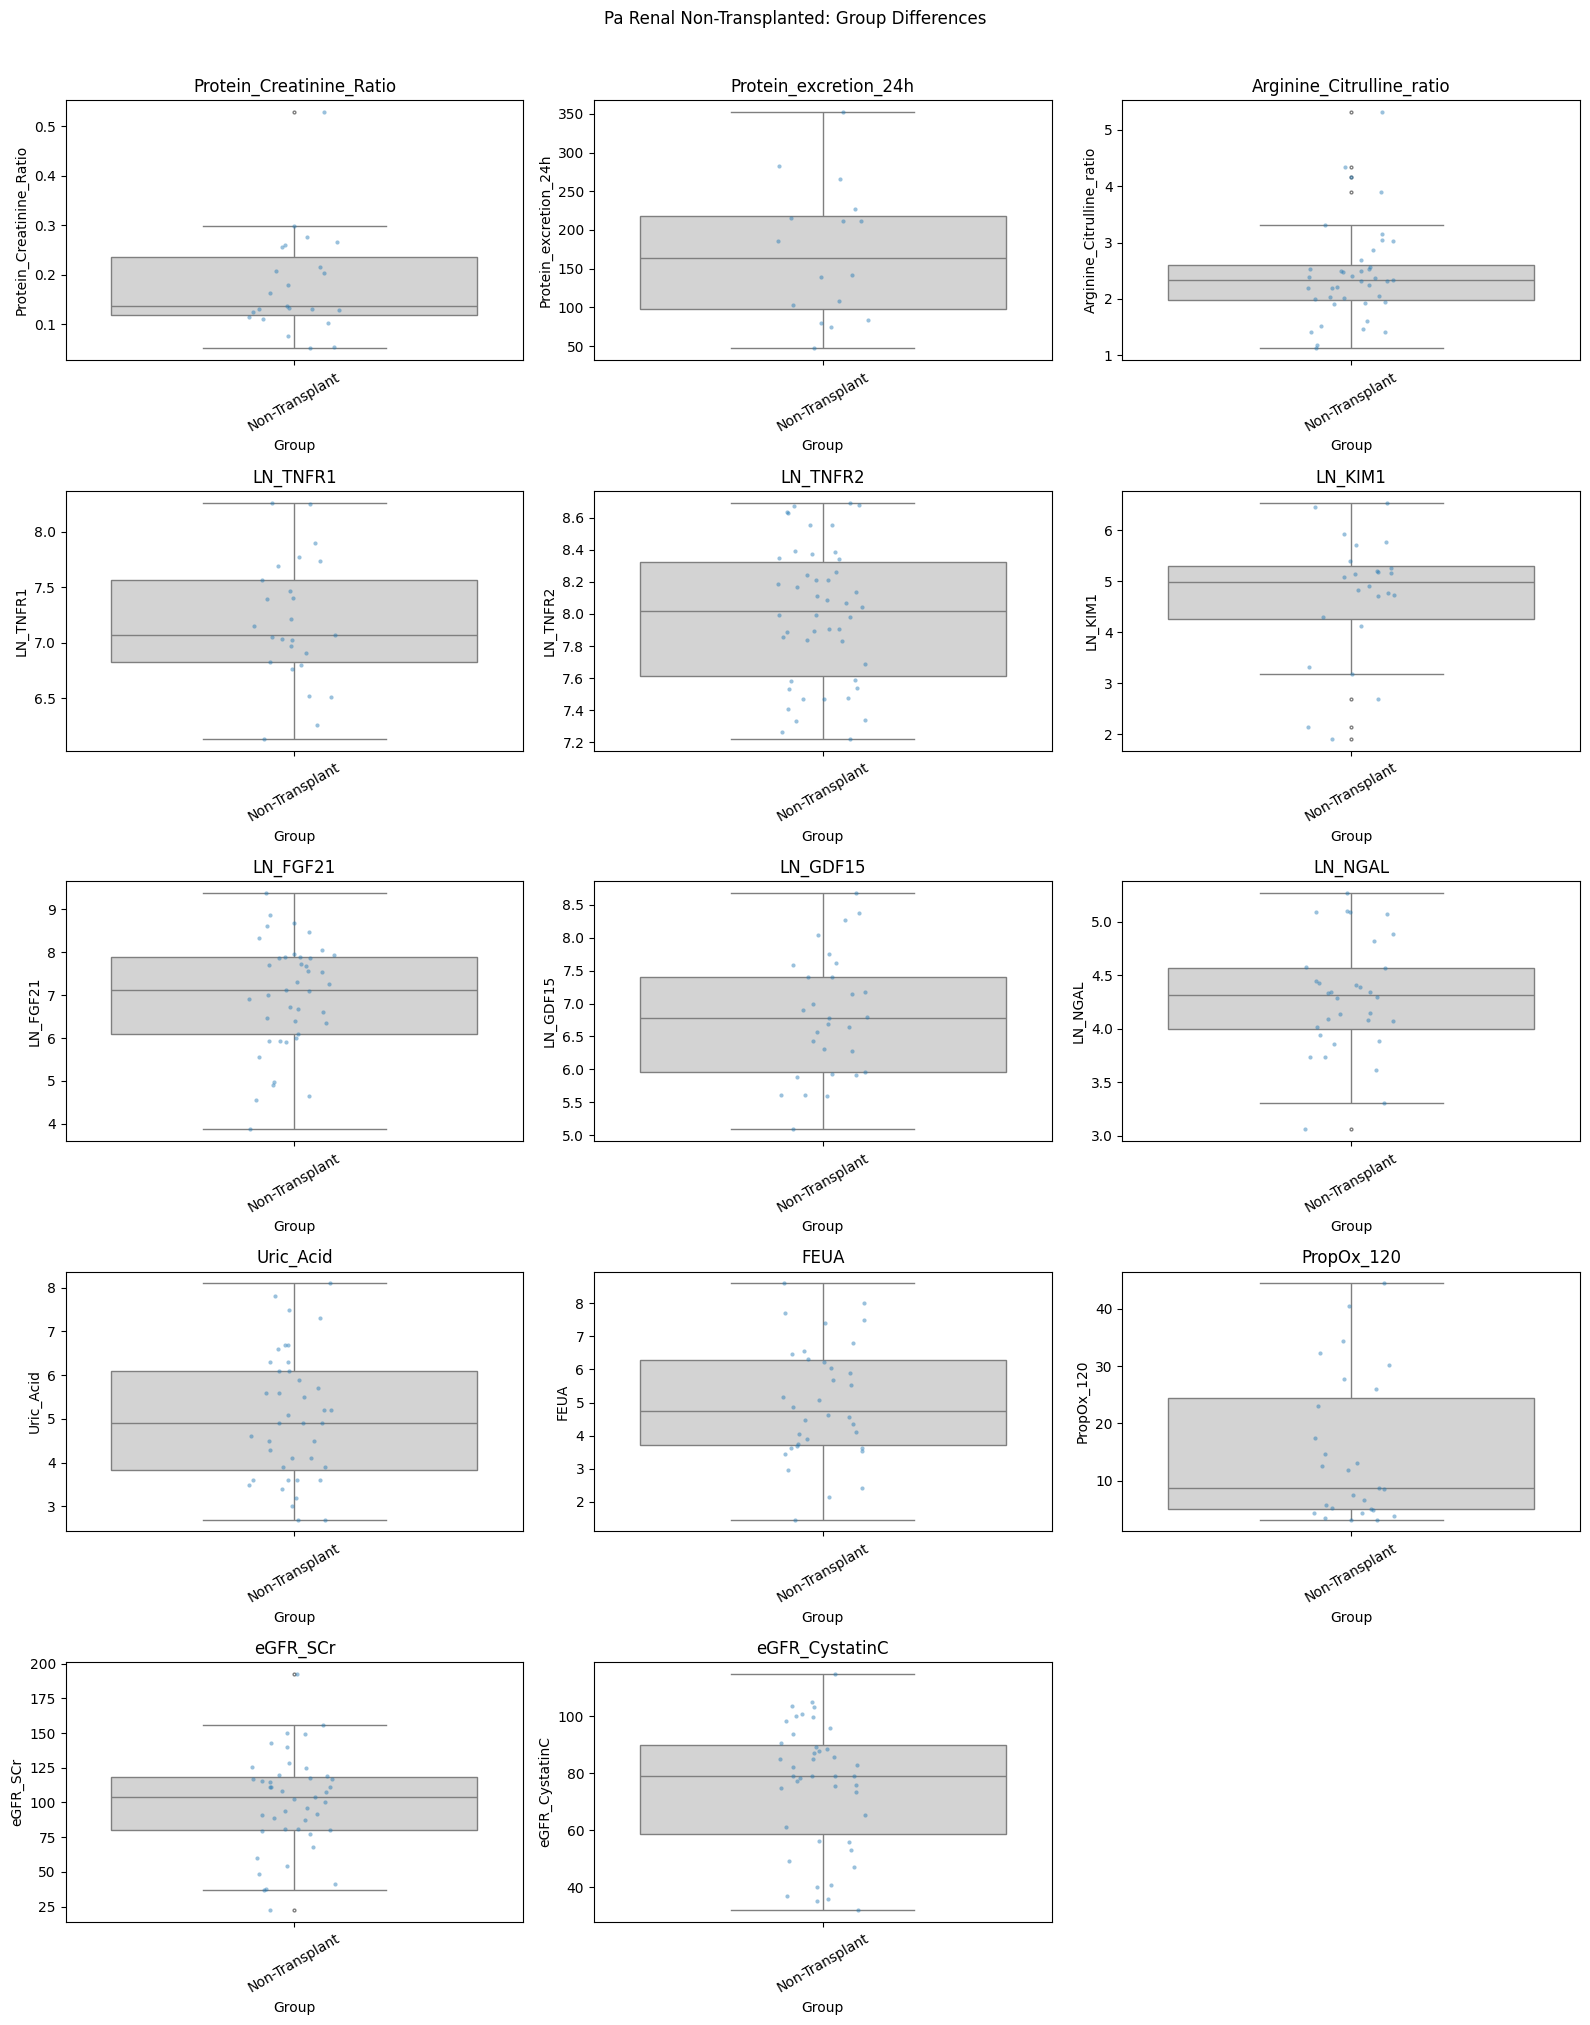

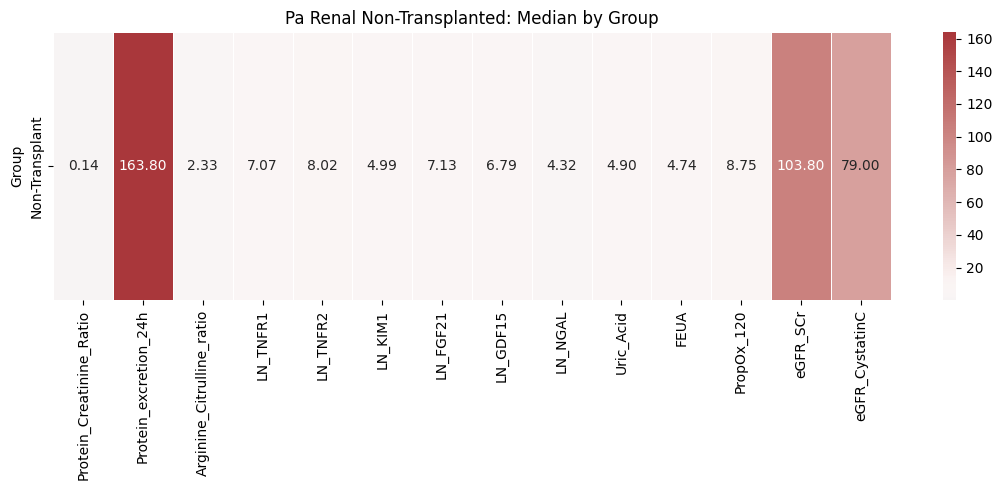

[Pa Renal Non-Transplanted] No pairwise tests ran.

=== Pa Renal Post-Transplant ===
Group
Transplant-L    5
Name: count, dtype: int64


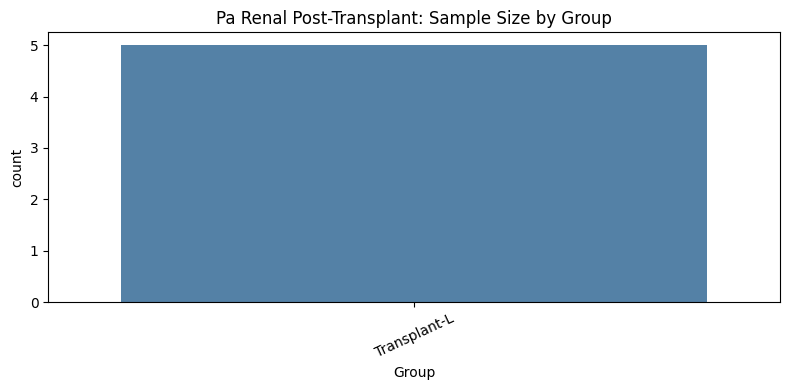

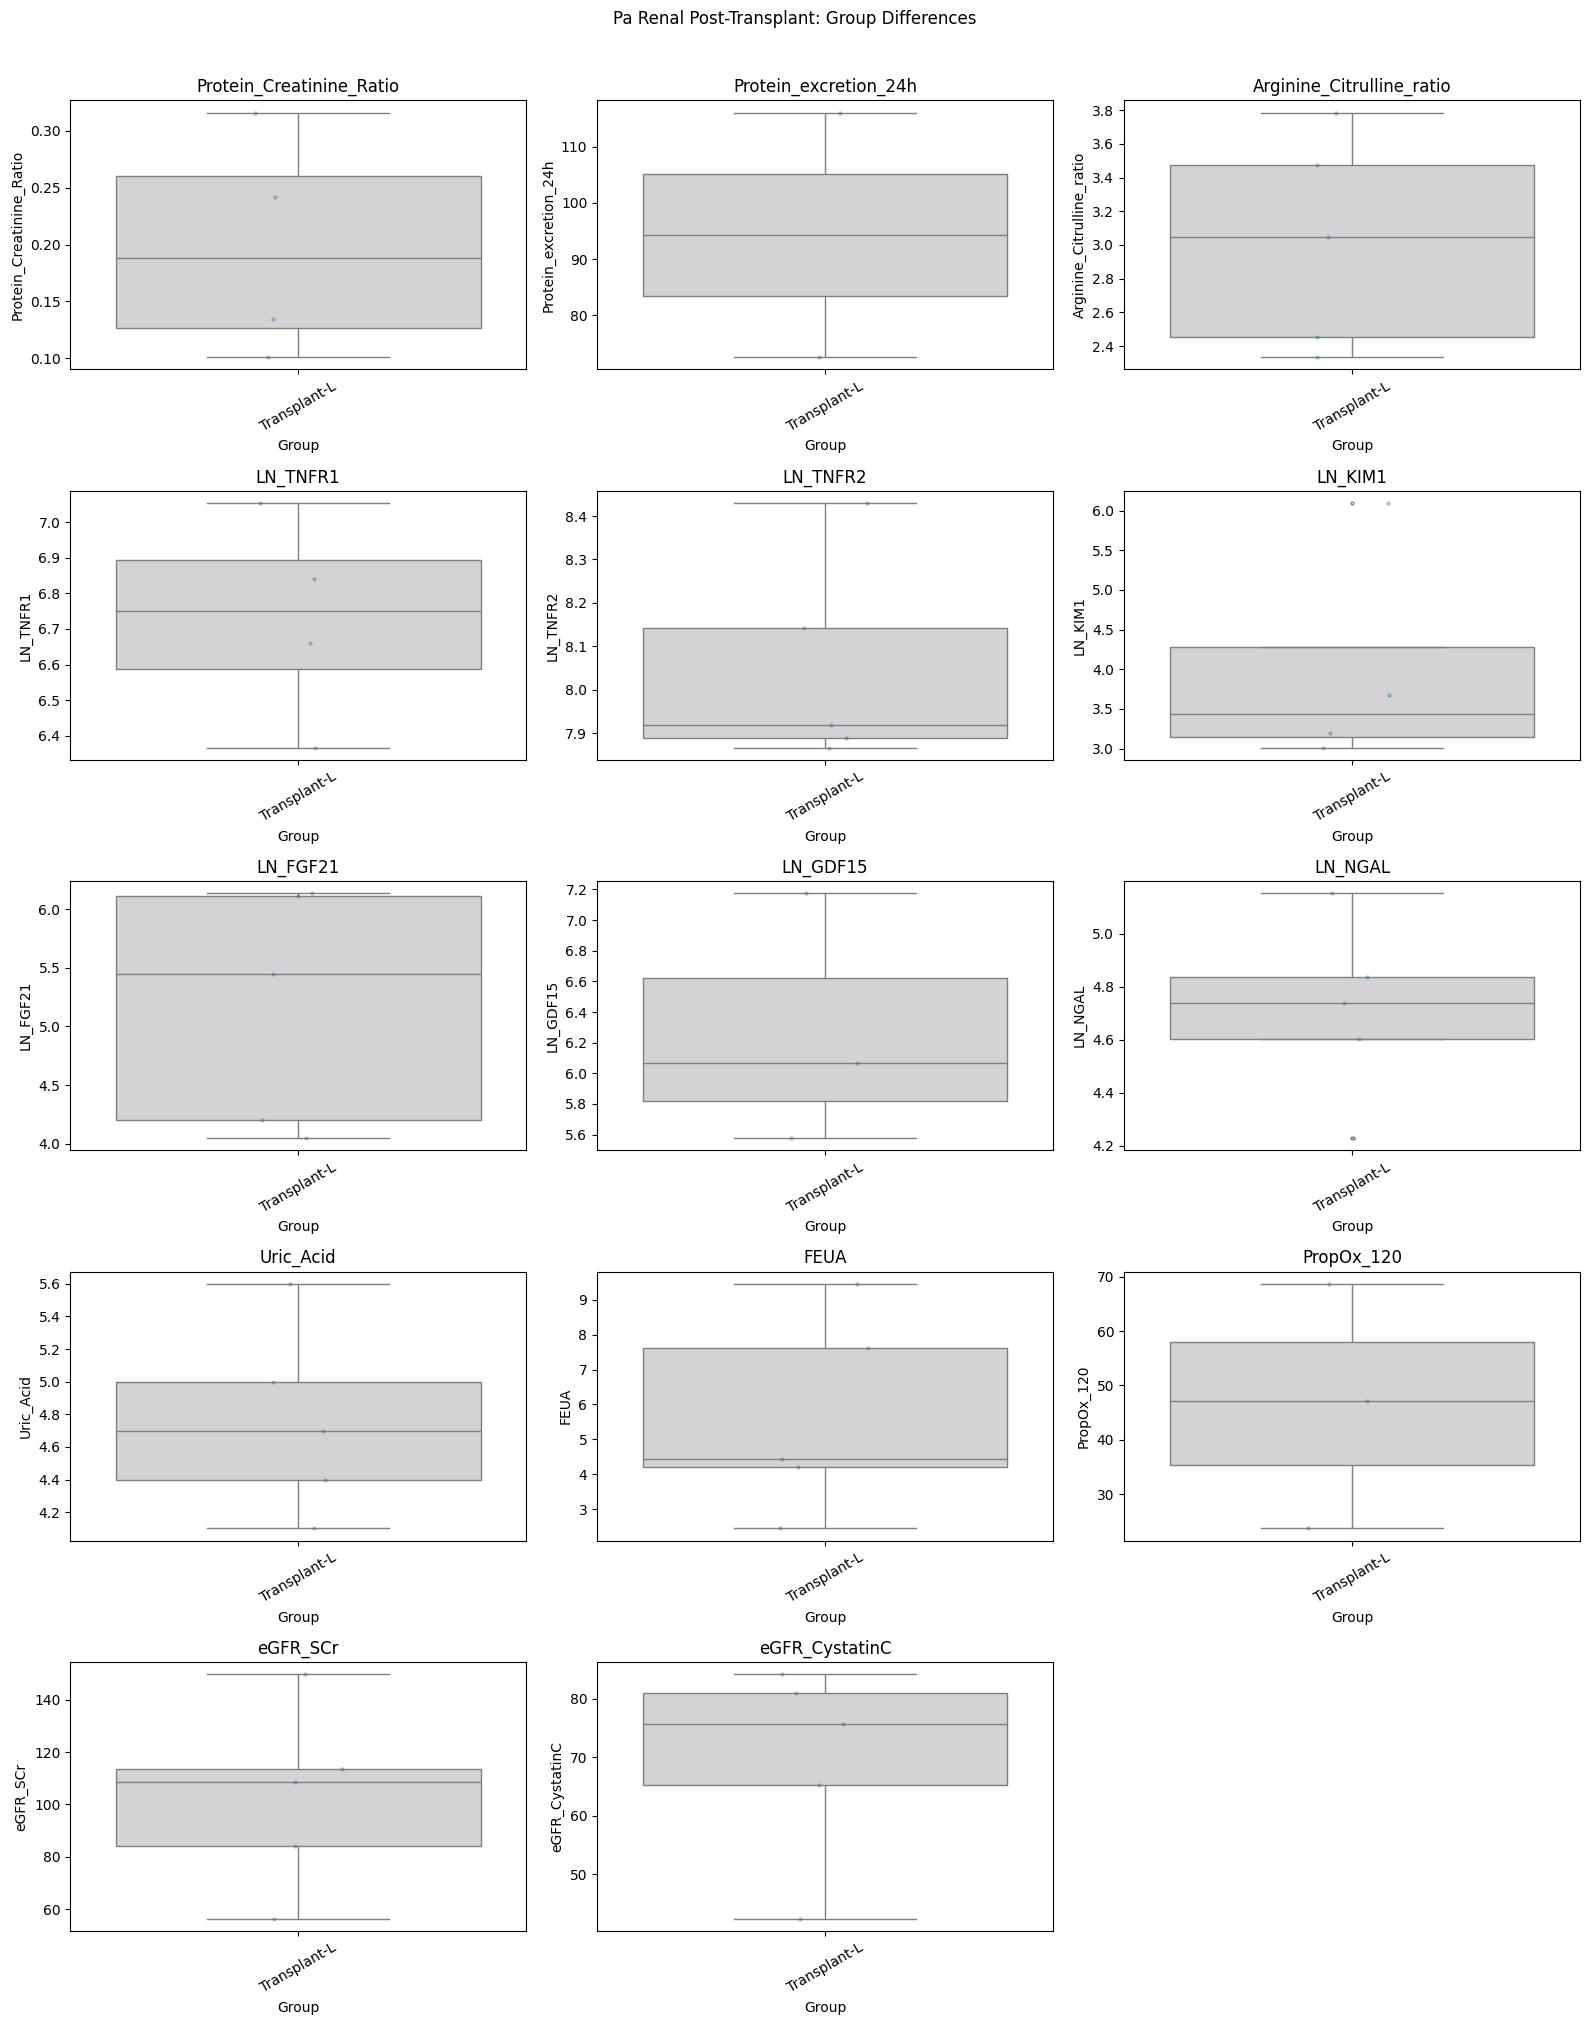

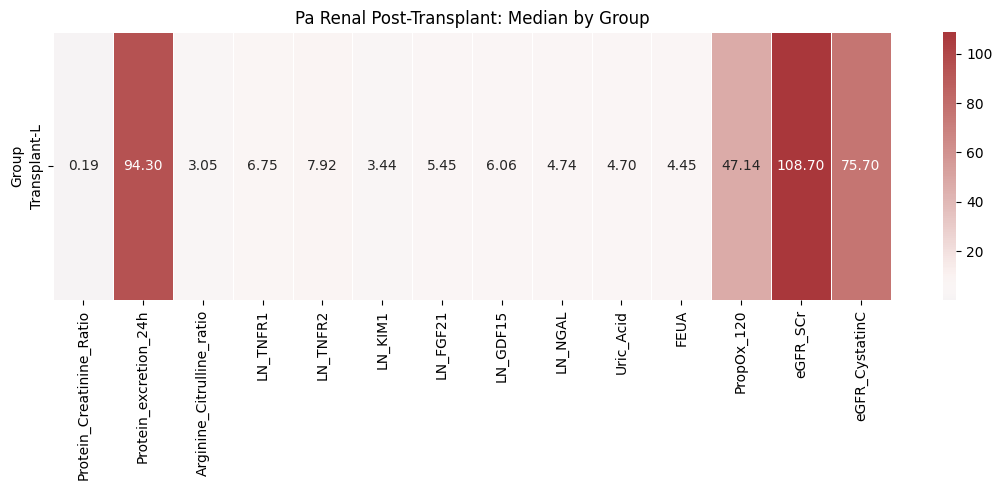

[Pa Renal Post-Transplant] No pairwise tests ran.


In [37]:
# -----------------------------
# Repeat group analyses for Pa renal datasets (raw + LN columns)
# -----------------------------

pa_datasets = {
    'Pa Renal Non-Transplanted': data_pa_non,
    'Pa Renal Post-Transplant': data_pa_post,
}

pa_sparse_results = []

for dataset_name, df_raw in pa_datasets.items():
    df = standardize_dataframe(df_raw)
    for col in DEFAULT_KEY_VARS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    df, group_order = build_group_labels(df)
    run_group_visuals(df, group_order, DEFAULT_KEY_VARS, dataset_name)
    res = run_sparse_pairwise(df, group_order, DEFAULT_KEY_VARS, dataset_name)
    if not res.empty:
        pa_sparse_results.append(res)

if pa_sparse_results:
    pa_sparse_all = pd.concat(pa_sparse_results, ignore_index=True)
    display(pa_sparse_all.head(20))
else:
    pa_sparse_all = pd.DataFrame()

log(raw) vs provided LN_* agreement:


,Dataset,Raw,LN_column,n_pairs,Pearson_r,Mean_abs_diff
0,MMA Non-Transplanted,TNFR1,LN_TNFR1,76,1.0,2.407431e-15
2,MMA Non-Transplanted,KIM1,LN_KIM1,81,1.0,2.406854e-15
3,MMA Non-Transplanted,FGF21,LN_FGF21,74,1.0,3.348673e-15
4,MMA Non-Transplanted,GDF15,LN_GDF15,59,1.0,2.227973e-15
5,MMA Non-Transplanted,NGAL,LN_NGAL,73,1.0,2.415115e-15
6,MMA Non-Transplanted,RBP4,LN_RBP4,8,1.0,2.886580e-14
7,MMA Non-Transplanted,TGFb1,LN_TGFb1,6,1.0,8.881784e-15
8,MMA Non-Transplanted,sMMA,LN_sMMA,67,1.0,2.459061e-15
1,MMA Non-Transplanted,TNFR2,LN_TNFR2,78,1.0,2.550666e-15
9,MMA Post-Transplant,TNFR1,LN_TNFR1,9,1.0,2.072416e-15


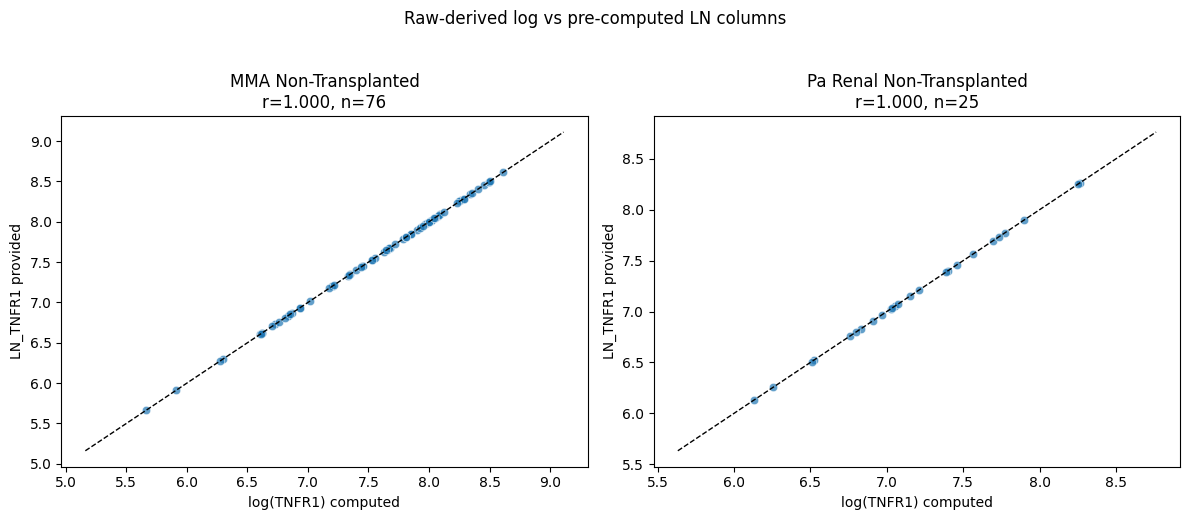

In [38]:
# -----------------------------
# Raw vs log validation and renal-vs-Pa comparison
# -----------------------------

# 1) Within-file check: log(raw) should match provided LN_* columns
validation_rows = []
for label, df_raw in {
    'MMA Non-Transplanted': data_mma_non,
    'MMA Post-Transplant': data_mma_post,
    'Pa Renal Non-Transplanted': data_pa_non,
    'Pa Renal Post-Transplant': data_pa_post,
}.items():
    df = standardize_dataframe(df_raw)
    for raw_col, ln_col in BIOMARKER_RAW_TO_LN.items():
        log_col = f'LOG_{raw_col}'
        if log_col not in df.columns or ln_col not in df.columns:
            continue
        sub = df[[log_col, ln_col]].apply(pd.to_numeric, errors='coerce').dropna()
        if len(sub) >= 3:
            validation_rows.append({
                'Dataset': label,
                'Raw': raw_col,
                'LN_column': ln_col,
                'n_pairs': len(sub),
                'Pearson_r': sub[log_col].corr(sub[ln_col]),
                'Mean_abs_diff': (sub[log_col] - sub[ln_col]).abs().mean(),
            })

validation_df = pd.DataFrame(validation_rows).sort_values(['Dataset', 'Pearson_r'], ascending=[True, False])
print('log(raw) vs provided LN_* agreement:')
display(validation_df)

# Scatter panel for strongest available biomarker in each dataset
plot_sets = [
    ('MMA Non-Transplanted', standardize_dataframe(data_mma_non), 'TNFR1', 'LN_TNFR1'),
    ('Pa Renal Non-Transplanted', standardize_dataframe(data_pa_non), 'TNFR1', 'LN_TNFR1'),
]

fig, axes = plt.subplots(1, len(plot_sets), figsize=(6 * len(plot_sets), 5))
if len(plot_sets) == 1:
    axes = [axes]

for ax, (name, df, raw_col, ln_col) in zip(axes, plot_sets):
    log_col = f'LOG_{raw_col}'
    sub = df[[log_col, ln_col]].apply(pd.to_numeric, errors='coerce').dropna()
    if sub.empty:
        ax.set_title(f'{name}\n(no paired data)')
        ax.axis('off')
        continue
    sns.scatterplot(data=sub, x=log_col, y=ln_col, ax=ax, alpha=0.7)
    lims = [min(sub.min().min(), sub.max().max()) - 0.5, max(sub.max().max(), sub.min().min()) + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(f'log({raw_col}) computed')
    ax.set_ylabel(f'{ln_col} provided')
    ax.set_title(f'{name}\nr={sub[log_col].corr(sub[ln_col]):.3f}, n={len(sub)}')

plt.suptitle('Raw-derived log vs pre-computed LN columns', y=1.03)
plt.tight_layout()
plt.show()